In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

*****first EDA****

In [2]:
# first EDA
df= pd.read_csv("BIKE DETAILS.csv")
df

,name,selling_price,year,seller_type,owner,km_driven,ex_showroom_price
0,Royal Enfield Classic 350,175000,2019,Individual,1st owner,350,NaN
1,Honda Dio,45000,2017,Individual,1st owner,5650,NaN
2,Royal Enfield Classic Gunmetal Grey,150000,2018,Individual,1st owner,12000,148114.0
3,Yamaha Fazer FI V 2.0 [2016-2018],65000,2015,Individual,1st owner,23000,89643.0
4,Yamaha SZ [2013-2014],20000,2011,Individual,2nd owner,21000,NaN
...,...,...,...,...,...,...,...
1056,Activa 3g,17000,2010,Individual,1st owner,500000,52000.0
1057,Honda CB twister,16000,2012,Individual,1st owner,33000,51000.0
1058,Bajaj Discover 125,15000,2013,Individual,2nd owner,35000,57000.0
1059,Honda CB Shine,12000,2009,Individual,1st owner,53000,58000.0


In [3]:
df.isnull().sum()

name                   0
selling_price          0
year                   0
seller_type            0
owner                  0
km_driven              0
ex_showroom_price    435
dtype: int64

In [4]:
# 1. What is the range of selling prices in the dataset
x,y=np.quantile(df["selling_price"],[0,1])
rangeOfSellingPrice= y-x
rangeOfSellingPrice


755000

In [5]:
#2. What is the median selling price for bikes in the dataset
df["selling_price"].median()

45000.0

In [6]:
df["seller_type"].unique()

array(['Individual', 'Dealer'], dtype=object)

In [7]:
# 3.  What is the most common seller type
count=df.groupby(["seller_type"])["seller_type"].count()
print("most common seller type is Individual\n",count)

most common seller type is Individual
 seller_type
Dealer           6
Individual    1055
Name: seller_type, dtype: int64


In [8]:
#4.How many bikes have driven more than 50,000 kilometers
df[df["km_driven"]>50000]["km_driven"].count()

170

In [9]:
#5. What is the average km_driven value for each ownership type
df.groupby("owner")["km_driven"].mean()

owner
1st owner     32816.583333
2nd owner     39288.991870
3rd owner     33292.181818
4th owner    311500.000000
Name: km_driven, dtype: float64

In [10]:
#6. What proportion of bikes are from the year 2015 or older
Before2015= df[df["year"]<=2015]["year"].count()
total= df["year"].count()
print("total number  of bikes are from the year 2015 or older",Before2015)
print("proportion of bikes ",Before2015/total)


total number  of bikes are from the year 2015 or older 601
proportion of bikes  0.5664467483506126


In [11]:
 # 7. What is the trend of missing values across the dataset
df.isnull().sum()

name                   0
selling_price          0
year                   0
seller_type            0
owner                  0
km_driven              0
ex_showroom_price    435
dtype: int64

In [12]:
# 8 . What is the highest ex_showroom_price recorded, and for which bike
highest_ex_showroom_price =df["ex_showroom_price"].max()
highest_ex_showroom_price_bike=df.sort_values(by="ex_showroom_price",ascending=False)["name"].iloc[0]
print("highest ex_showroom_price ",highest_ex_showroom_price)
print("highest ex_showroom_price of bike ",highest_ex_showroom_price_bike)

highest ex_showroom_price  1278000.0
highest ex_showroom_price of bike  Harley-Davidson Street Bob


In [13]:
#9 What is the total number of bikes listed by each seller type
df.groupby("seller_type")["seller_type"].count()

seller_type
Dealer           6
Individual    1055
Name: seller_type, dtype: int64

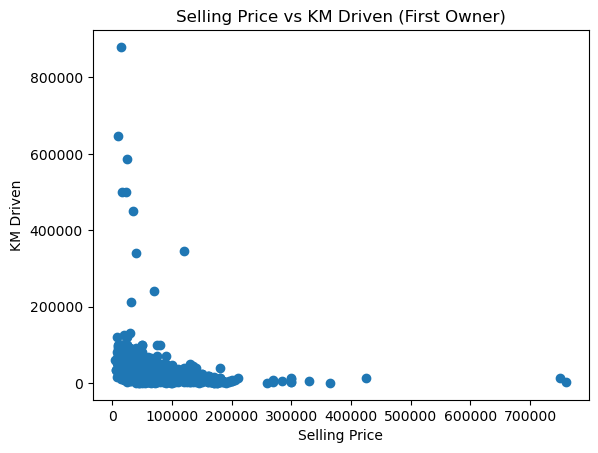

correlation of both is  -0.24348174844965736


In [14]:
#10. What is the relationship between selling_price and km_driven for first-owner bikes
new_df=df[df["owner"]=="1st owner"]
import matplotlib.pyplot as plt
plt.scatter(df["selling_price"],df["km_driven"])
plt.ylabel("KM Driven")
plt.xlabel("Selling Price")
plt.title("Selling Price vs KM Driven (First Owner)")
plt.show()

correlation = new_df['selling_price'].corr(new_df['km_driven'])
print("correlation of both is ",correlation)


Upper fence: 87250.0
Lower fence: -30750.0


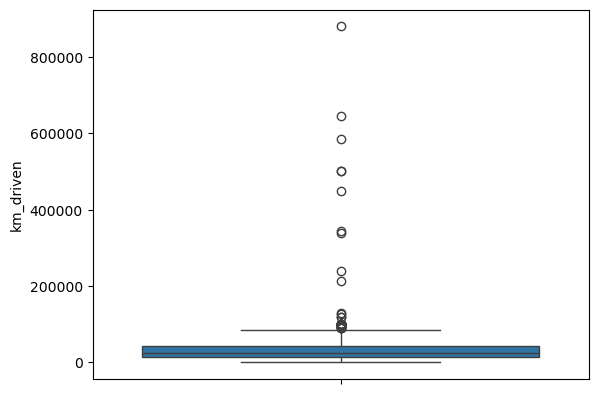

In [15]:
#11. Identify and remove outliers in the km_driven column using the IQR method
sns.boxplot(df["km_driven"])

q1,q3=np.quantile(df["km_driven"],[.25,.75])
IQR = q3-q1
upper_fence = q3+1.5*IQR
lower_fence =q1-1.5*IQR

print("Upper fence:", upper_fence)
print("Lower fence:", lower_fence)

median = df["km_driven"].median()
#identify
outliers_data = df[ (df["km_driven"]>=upper_fence) | (df["km_driven"]<=lower_fence)]["km_driven"]

#imputation with median
df["km_driven"]=np.where((df["km_driven"]>=upper_fence) | (df["km_driven"]<=lower_fence),median,df["km_driven"])


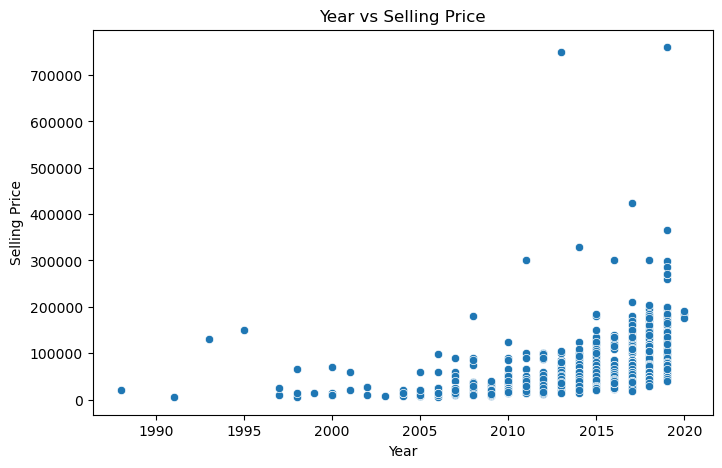

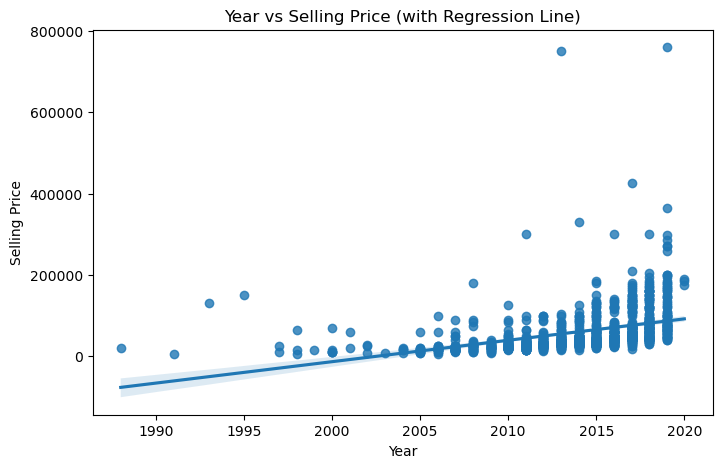

Correlation: 0.402188400614744


In [16]:
#12. Perform a bivariate analysis to visualize the relationship between year and selling_price


plt.figure(figsize=(8,5))
sns.scatterplot(x=df['year'], y=df['selling_price'])
plt.title("Year vs Selling Price")
plt.xlabel("Year")
plt.ylabel("Selling Price")
plt.show()

plt.figure(figsize=(8,5))
sns.regplot(x=df['year'], y=df['selling_price'])
plt.title("Year vs Selling Price (with Regression Line)")
plt.xlabel("Year")
plt.ylabel("Selling Price")
plt.show()

corr = df['year'].corr(df['selling_price'])
print("Correlation:", corr)



In [17]:
#13. What is the average depreciation in selling price based on the bike's age (current year - manufacturing year)
import datetime
current_year = datetime.datetime.now().year
df['age'] = current_year - df['year']
age_group = df.groupby('age')['selling_price'].mean().reset_index()
print(age_group)

    age  selling_price
0     5  183333.333333
1     6  119689.511628
2     7   87660.374046
3     8   78894.736842
4     9   58469.018692
5    10   56500.000000
6    11   48668.131868
7    12   51136.986301
8    13   35748.400000
9    14   35655.721311
10   15   31793.333333
11   16   22267.857143
12   17   34289.285714
13   18   24927.586207
14   19   23380.000000
15   20   16978.571429
16   21   15100.000000
17   22    8000.000000
18   23   20666.666667
19   24   40000.000000
20   25   20833.333333
21   26   15000.000000
22   27   28333.333333
23   28   17500.000000
24   30  150000.000000
25   32  130000.000000
26   34    6000.000000
27   37   20000.000000


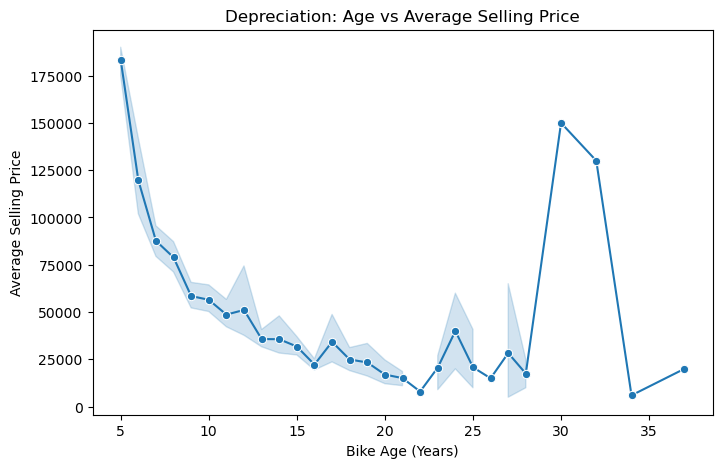

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.lineplot(x=df['age'], y=df['selling_price'], marker='o')
plt.title("Depreciation: Age vs Average Selling Price")
plt.xlabel("Bike Age (Years)")
plt.ylabel("Average Selling Price")
plt.show()


In [19]:
#14.  Which bike names are priced significantly above the average price for their manufacturing year
year_avg=df.groupby("year")["selling_price"].mean().reset_index()
year_avg.rename(columns={"selling_price": "year_avg_price"}, inplace=True)
df = df.merge(year_avg, on="year", how="left")


df['price_diff'] = df['selling_price'] - df['year_avg_price']
df['percent_above_avg'] = df['price_diff'] / df['year_avg_price']

# filter bikes where price is 20% above average
high_priced_bikes = df[df['percent_above_avg'] > 0.20]["name"].reset_index()
high_priced_bikes

,index,name
0,0,Royal Enfield Classic 350
1,2,Royal Enfield Classic Gunmetal Grey
2,7,Royal Enfield Bullet 350 [2007-2011]
3,13,Yamaha YZF R3
4,17,Yamaha YZF R15 S
...,...,...
228,984,Royal Enfield Classic 500
229,985,Royal Enfield Classic 500
230,1005,TVS Apache RTR 160
231,1008,Bajaj Pulsar 220 F


In [20]:
del df['price_diff']
del df["percent_above_avg"]
del df["age"]

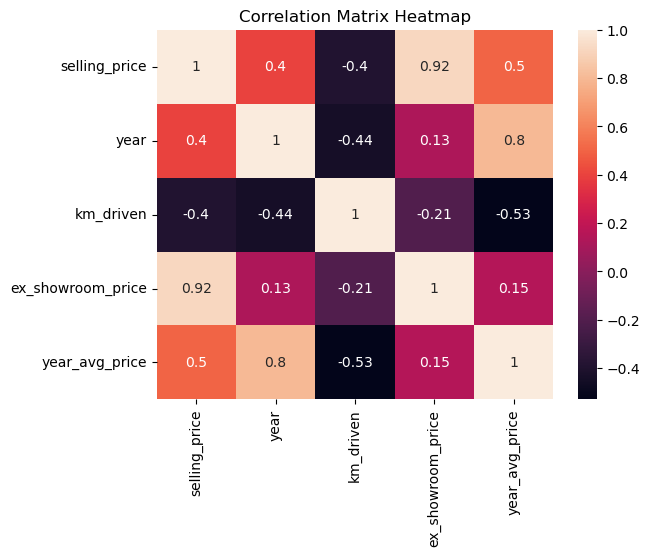

In [21]:
#15 Develop a correlation matrix for numeric columns and visualize it using a heatmap
corr= df.corr(numeric_only=True)
sns.heatmap(corr,annot=True)
plt.title("Correlation Matrix Heatmap")
plt.show()

------------------------------------------------------------------------------------------------------------------

***second EDA***

-----------------------------------------------------------------

In [22]:
df= pd.read_csv("Car Sale.csv")
df

,Car_id,Date,Customer Name,Gender,Annual Income,Dealer_Name,Company,Model,Engine,Transmission,Color,Price ($),Dealer_No,Body Style,Phone,Dealer_Region
0,C_CND_000001,1/2/2022,Geraldine,Male,13500,Buddy Storbeck's Diesel Service Inc,Ford,Expedition,DoubleÂ Overhead Camshaft,Auto,Black,26000,06457-3834,SUV,8264678,Middletown
1,C_CND_000002,1/2/2022,Gia,Male,1480000,C & M Motors Inc,Dodge,Durango,DoubleÂ Overhead Camshaft,Auto,Black,19000,60504-7114,SUV,6848189,Aurora
2,C_CND_000003,1/2/2022,Gianna,Male,1035000,Capitol KIA,Cadillac,Eldorado,Overhead Camshaft,Manual,Red,31500,38701-8047,Passenger,7298798,Greenville
3,C_CND_000004,1/2/2022,Giselle,Male,13500,Chrysler of Tri-Cities,Toyota,Celica,Overhead Camshaft,Manual,Pale White,14000,99301-3882,SUV,6257557,Pasco
4,C_CND_000005,1/2/2022,Grace,Male,1465000,Chrysler Plymouth,Acura,TL,DoubleÂ Overhead Camshaft,Auto,Red,24500,53546-9427,Hatchback,7081483,Janesville
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23901,C_CND_023902,12/31/2023,Martin,Male,13500,C & M Motors Inc,Plymouth,Voyager,Overhead Camshaft,Manual,Red,12000,60504-7114,Passenger,8583598,Pasco
23902,C_CND_023903,12/31/2023,Jimmy,Female,900000,Ryder Truck Rental and Leasing,Chevrolet,Prizm,DoubleÂ Overhead Camshaft,Auto,Black,16000,06457-3834,Hardtop,7914229,Middletown
23903,C_CND_023904,12/31/2023,Emma,Male,705000,Chrysler of Tri-Cities,BMW,328i,Overhead Camshaft,Manual,Red,21000,99301-3882,Sedan,7659127,Scottsdale
23904,C_CND_023905,12/31/2023,Victoire,Male,13500,Chrysler Plymouth,Chevrolet,Metro,DoubleÂ Overhead Camshaft,Auto,Black,31000,53546-9427,Passenger,6030764,Austin


In [23]:
df.isnull().sum()

Car_id           0
Date             0
Customer Name    1
Gender           0
Annual Income    0
Dealer_Name      0
Company          0
Model            0
Engine           0
Transmission     0
Color            0
Price ($)        0
Dealer_No        0
Body Style       0
Phone            0
Dealer_Region    0
dtype: int64

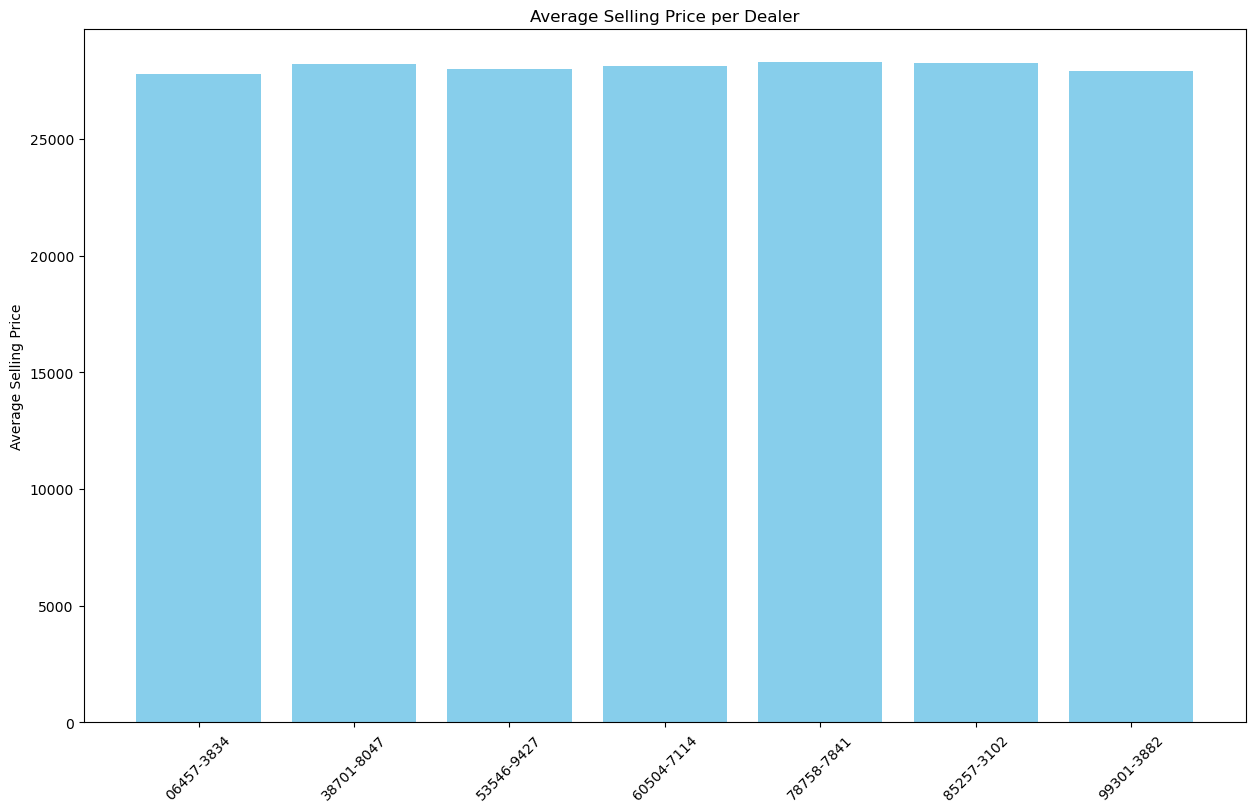

avg_price_per_dealer:     Dealer_No      Price ($)
0  06457-3834  27771.614943
1  38701-8047  28208.618455
2  53546-9427  28009.712038
3  60504-7114  28134.025879
4  78758-7841  28272.412204
5  85257-3102  28259.141059
6  99301-3882  27920.853768


In [24]:
#1. What is the average selling price of cars for each dealer, and how does it compare across different dealers
avg_price_per_dealer = df.groupby("Dealer_No ")["Price ($)"].mean().reset_index()

plt.figure(figsize=(15,9))
plt.bar(avg_price_per_dealer['Dealer_No '], avg_price_per_dealer['Price ($)'], color='skyblue')
plt.xticks(rotation=45)
plt.ylabel('Average Selling Price')
plt.title('Average Selling Price per Dealer')

plt.show()
print("avg_price_per_dealer: ",avg_price_per_dealer)

In [25]:
#2. Which car brand (Company) has the highest variation in prices, and what does this tell us about the pricing trends
price_variation= df.groupby("Company")["Price ($)"].std().reset_index()
price_variation = price_variation.rename(columns={'company':'price_std_dev'})
price_variation.sort_values(by="Price ($)",ascending=False)

,Company,Price ($)
15,Lincoln,19658.050211
24,Saab,19653.740089
4,Cadillac,19517.120220
21,Plymouth,19065.997338
14,Lexus,17852.923492
3,Buick,17142.232626
17,Mercury,16445.172195
19,Nissan,16214.264017
25,Saturn,15990.223671
8,Ford,15849.090227


In [26]:
#3. What is the distribution of car prices for each transmission type, and how do the interquartile ranges compare
price_distribution= df.groupby("Transmission")["Price ($)"].std().reset_index()
print("distribution of car prices for each transmission type",price_distribution)
print("")
iqr = df.groupby('Transmission')['Price ($)'].agg(
    Q1=lambda x: x.quantile(0.25),
    Q3=lambda x: x.quantile(0.75)
).reset_index()

iqr['IQR'] = iqr['Q3'] - iqr['Q1']
print("iqr compare ",iqr)

distribution of car prices for each transmission type   Transmission     Price ($)
0         Auto  13747.070597
1       Manual  15862.871978

iqr compare    Transmission       Q1       Q3      IQR
0         Auto  19000.0  35500.0  16500.0
1       Manual  17000.0  34000.0  17000.0


                count          mean           std     min      25%      50%  \
Dealer_Region                                                                 
Aurora         3130.0  28334.626837  15026.207252  9000.0  18001.0  23000.0   
Austin         4135.0  28341.603628  14903.884549  9000.0  18001.0  23801.0   
Greenville     3128.0  28180.819054  15101.538328  1200.0  18001.0  22500.0   
Janesville     3821.0  27833.350955  14344.995638  4300.0  18001.0  23000.0   
Middletown     3128.0  27856.338875  14619.842395  1700.0  18000.0  22750.0   
Pasco          3131.0  28119.039923  14659.315941  9000.0  18500.5  23000.0   
Scottsdale     3433.0  27954.958928  14902.916820  1450.0  18000.0  22600.0   

                   75%      max  
Dealer_Region                    
Aurora         35000.0  85800.0  
Austin         35001.0  85601.0  
Greenville     34500.0  85200.0  
Janesville     34000.0  85400.0  
Middletown     34000.0  85300.0  
Pasco          34000.0  85600.0  
Scottsdale     3

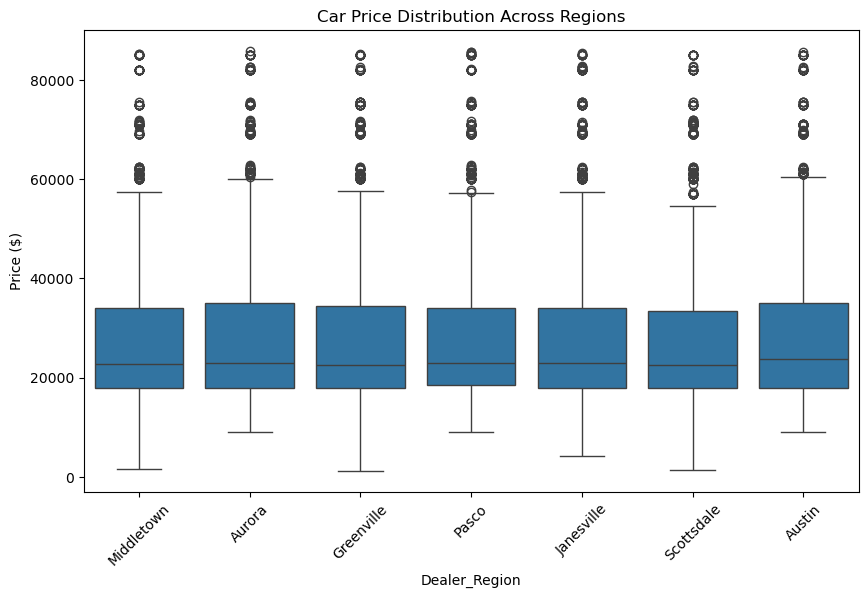

  Dealer_Region       Q1       Q3      IQR
0        Aurora  18001.0  35000.0  16999.0
1        Austin  18001.0  35001.0  17000.0
2    Greenville  18001.0  34500.0  16499.0
3    Janesville  18001.0  34000.0  15999.0
4    Middletown  18000.0  34000.0  16000.0
5         Pasco  18500.5  34000.0  15499.5
6    Scottsdale  18000.0  33500.0  15500.0


In [27]:
#4. What is the distribution of car prices across different regions
region_distribution = df.groupby("Dealer_Region")["Price ($)"].describe()
print(region_distribution)


plt.figure(figsize=(10,6))
sns.boxplot(x='Dealer_Region', y='Price ($)', data=df)
plt.title('Car Price Distribution Across Regions')
plt.xticks(rotation=45)
plt.show()

iqr_region = df.groupby('Dealer_Region')["Price ($)"].agg(
    Q1=lambda x: x.quantile(0.25),
    Q3=lambda x: x.quantile(0.75)
).reset_index()

iqr_region['IQR'] = iqr_region['Q3'] - iqr_region['Q1']
print(iqr_region)


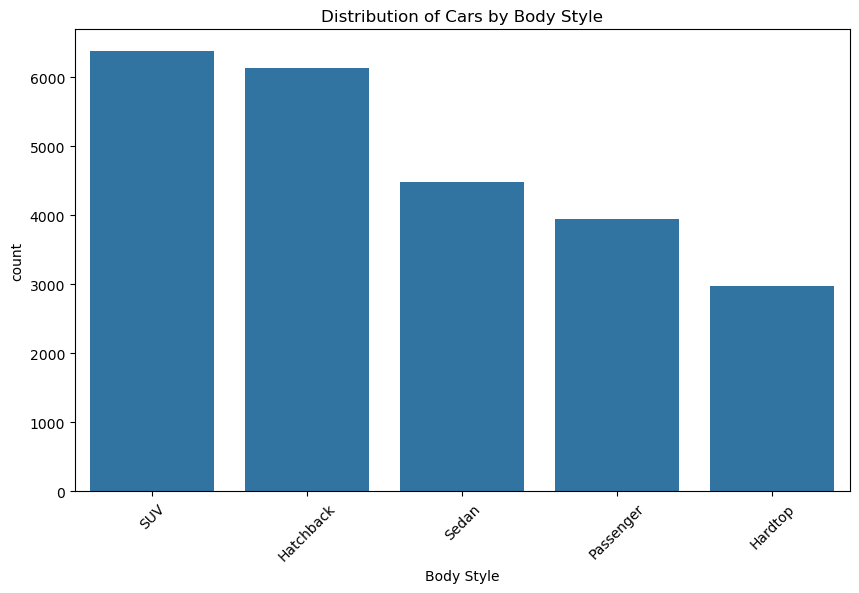

In [28]:
#5 What is the distribution of cars based on body styles
body_style_distribution = df["Body Style"].value_counts().reset_index()
body_style_distribution


plt.figure(figsize=(10,6))
sns.barplot(x='Body Style', y='count', data=body_style_distribution)
plt.title('Distribution of Cars by Body Style')
plt.xticks(rotation=45)
plt.show()

      Gender  Annual Income  Average_Selling_Price
0     Female          13500           28132.038732
1     Female         106000           46001.000000
2     Female         121000           20000.000000
3     Female         190000           19001.000000
4     Female         211000           51000.000000
...      ...            ...                    ...
3437    Male        6600000           39000.000000
3438    Male        6800000           15000.000000
3439    Male        7650000           21000.000000
3440    Male        8000000           85000.000000
3441    Male       11200000           26001.000000

[3442 rows x 3 columns]


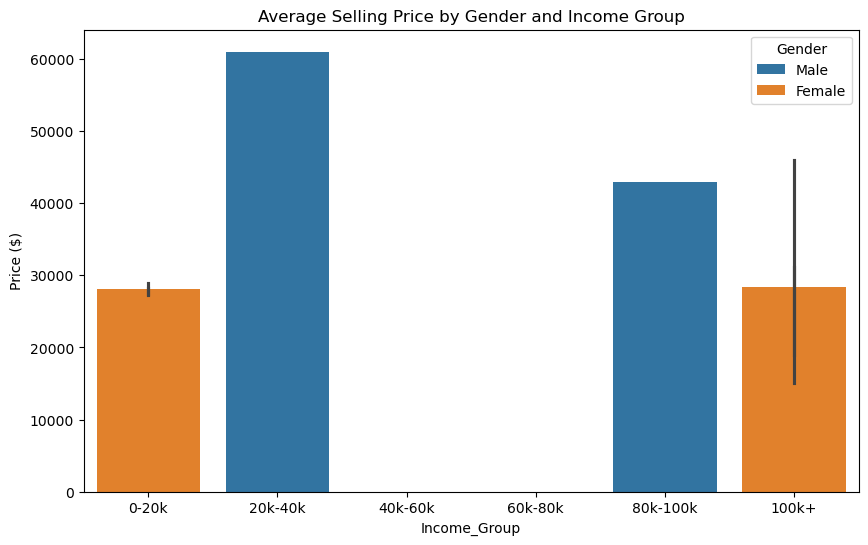

In [29]:
 #6. How does the average selling price of cars vary by customer gender and annual income
price_by_gender_income = df.groupby(['Gender', 'Annual Income'])['Price ($)'].mean().reset_index()
price_by_gender_income = price_by_gender_income.rename(columns={'Price ($)': 'Average_Selling_Price'})
print(price_by_gender_income)

bins = [0, 20000, 40000, 60000, 80000, 100000, 200000]
labels = ['0-20k', '20k-40k', '40k-60k', '60k-80k', '80k-100k', '100k+']

df['Income_Group'] = pd.cut(df['Annual Income'], bins=bins, labels=labels)

plt.figure(figsize=(10,6))
sns.barplot(x='Income_Group', y='Price ($)', hue='Gender', data=df)
plt.title('Average Selling Price by Gender and Income Group')
plt.show()



In [30]:
#7 .What is the distribution of car prices by region, and how does the number of cars sold vary by region
distribution =df.groupby("Dealer_Region")["Price ($)"].var()
CarsSoldRegions=df.groupby("Dealer_Region")["Price ($)"].describe()
print("the distribution of car prices by region",distribution)
print("the number of cars sold vary by region",CarsSoldRegions)

the distribution of car prices by region Dealer_Region
Aurora        2.257869e+08
Austin        2.221258e+08
Greenville    2.280565e+08
Janesville    2.057789e+08
Middletown    2.137398e+08
Pasco         2.148955e+08
Scottsdale    2.220969e+08
Name: Price ($), dtype: float64
the number of cars sold vary by region                 count          mean           std     min      25%      50%  \
Dealer_Region                                                                 
Aurora         3130.0  28334.626837  15026.207252  9000.0  18001.0  23000.0   
Austin         4135.0  28341.603628  14903.884549  9000.0  18001.0  23801.0   
Greenville     3128.0  28180.819054  15101.538328  1200.0  18001.0  22500.0   
Janesville     3821.0  27833.350955  14344.995638  4300.0  18001.0  23000.0   
Middletown     3128.0  27856.338875  14619.842395  1700.0  18000.0  22750.0   
Pasco          3131.0  28119.039923  14659.315941  9000.0  18500.5  23000.0   
Scottsdale     3433.0  27954.958928  14902.916820  14

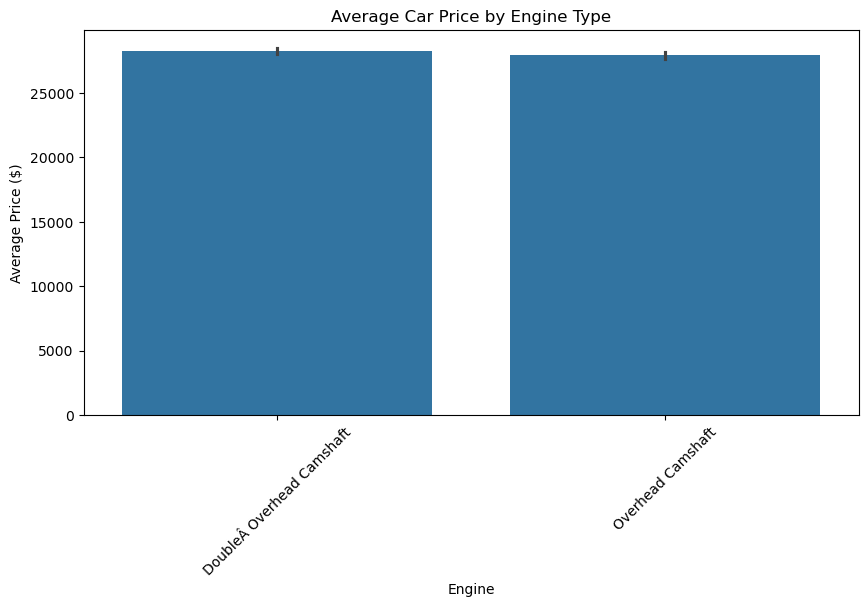

In [31]:
#8. How does the average car price differ between cars with different engine sizes
df.groupby(["Company","Engine"])["Price ($)"].mean().sort_values()

plt.figure(figsize=(10, 5))
sns.barplot(x="Engine", y="Price ($)", data=df, estimator='mean')
plt.title("Average Car Price by Engine Type")
plt.xticks(rotation=45)
plt.ylabel("Average Price ($)")
plt.show()

                count          mean           std      min      25%      50%  \
Annual Income                                                                  
10080             1.0  22801.000000           NaN  22801.0  22801.0  22801.0   
13500          5273.0  27878.981415  14904.756077   1200.0  18000.0  22001.0   
24000             1.0  61001.000000           NaN  61001.0  61001.0  61001.0   
85000             1.0  43000.000000           NaN  43000.0  43000.0  43000.0   
106000            1.0  46001.000000           NaN  46001.0  46001.0  46001.0   
...               ...           ...           ...      ...      ...      ...   
6600000           1.0  39000.000000           NaN  39000.0  39000.0  39000.0   
6800000           1.0  15000.000000           NaN  15000.0  15000.0  15000.0   
7650000           1.0  21000.000000           NaN  21000.0  21000.0  21000.0   
8000000           1.0  85000.000000           NaN  85000.0  85000.0  85000.0   
11200000          1.0  26001.000000     

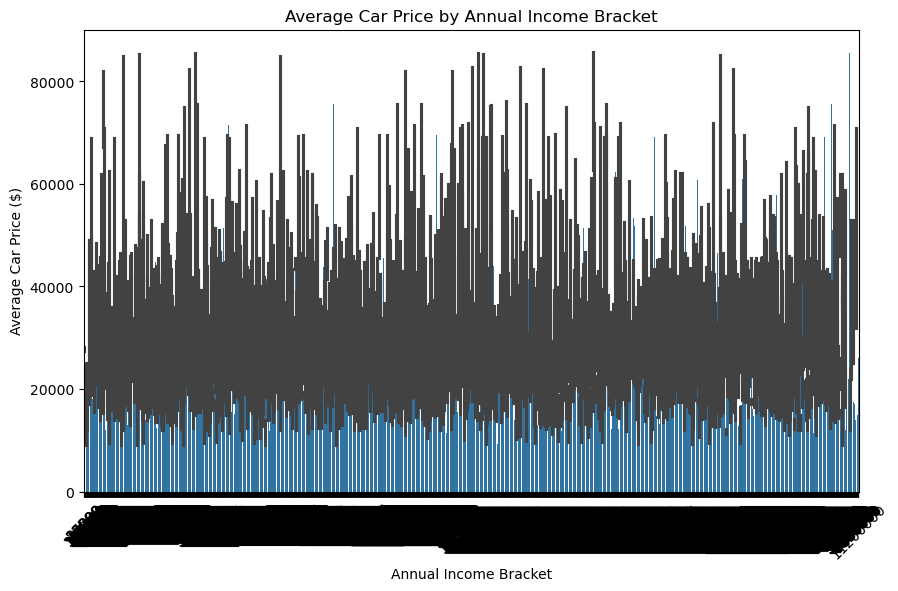

In [32]:
#9  How do car prices vary based on the customer’s annual income bracket
describe= df.groupby("Annual Income")["Price ($)"].describe()
print(describe)

plt.figure(figsize=(10, 6))
sns.barplot(x="Annual Income", y="Price ($)",data=df)
plt.title("Average Car Price by Annual Income Bracket")
plt.xlabel("Annual Income Bracket")
plt.ylabel("Average Car Price ($)")
plt.xticks(rotation=45)
plt.show()


Index(['Diamante', 'Silhouette', 'Prizm', 'Passat', 'Ram Pickup'], dtype='object', name='Model')


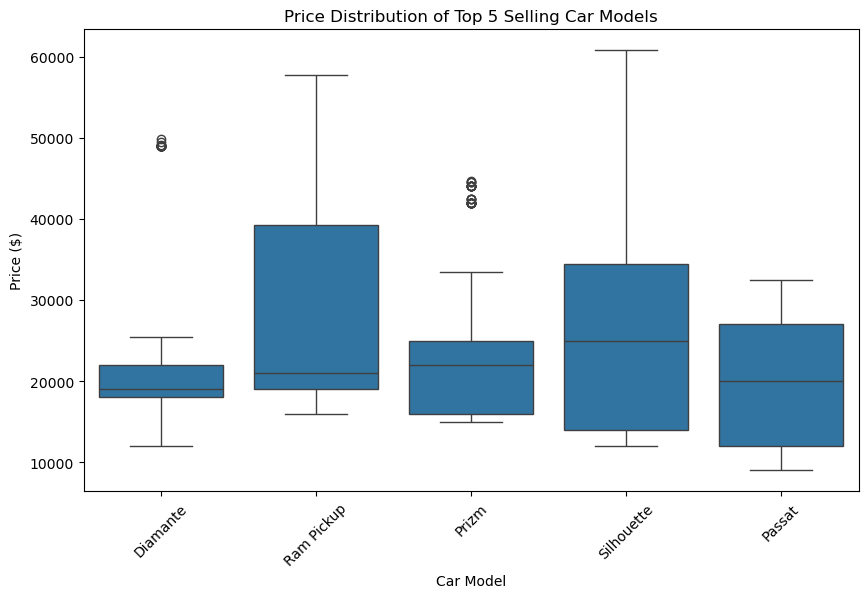

In [33]:
#10 What are the top 5 car models with the highest number of sales, and how does their price distribution look
top_5_models = df["Model"].value_counts().head(5).index
print(top_5_models)

top_models_df = df[df["Model"].isin(top_5_models)]
top_models_df


plt.figure(figsize=(10, 6))
sns.boxplot(x="Model", y="Price ($)", data=top_models_df)
plt.title("Price Distribution of Top 5 Selling Car Models")
plt.xlabel("Car Model")
plt.ylabel("Price ($)")
plt.xticks(rotation=45)
plt.show()


In [34]:
#11 How does car price vary with engine size across different car colors, and which colors have the highest price variation
df.groupby(["Engine","Color"])["Price ($)"].var()
df.groupby("Color")["Price ($)"].var().sort_values(ascending=False)

Color
Red           2.408506e+08
Black         2.336638e+08
Pale White    1.981717e+08
Name: Price ($), dtype: float64

Date of Sale
January       790
February      735
March        1535
April        1655
May          1895
June         1715
July         1725
August       1705
September    3305
October      1830
November     3470
December     3546
Name: count, dtype: int64


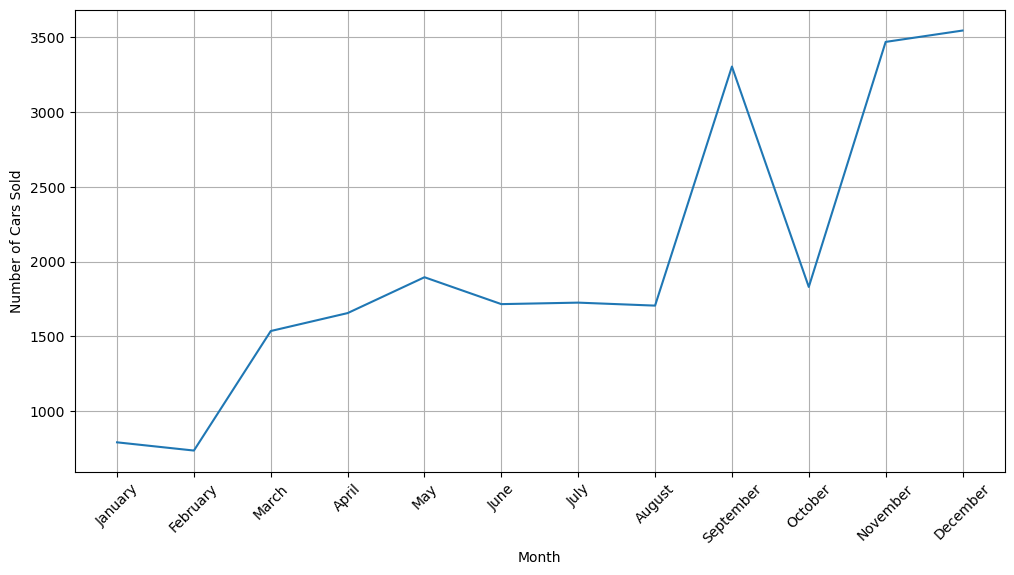

In [35]:
#12 Is there any seasonal trend in car sales based on the date of sale
import datetime
df["Date of Sale"] = pd.to_datetime(df["Date"])
df["Date of Sale"]=df["Date of Sale"].dt.month_name()
monthly_sales=df["Date of Sale"].value_counts().reindex([
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
])
print(monthly_sales)
plt.figure(figsize=(12,6))
sns.lineplot(x=monthly_sales.index,y=monthly_sales.values)
plt.xlabel("Month")
plt.ylabel("Number of Cars Sold")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


                          count          mean           std      min      25%  \
Body Style Transmission                                                         
Hardtop    Auto          1408.0  31520.188210  13687.756740  12000.0  21001.0   
           Manual        1563.0  27016.943698  14072.501848  11000.0  17575.5   
Hatchback  Auto          3458.0  25910.544824  13144.014337   4200.0  18001.0   
           Manual        2670.0  28702.550562  16284.049616   1700.0  17000.0   
Passenger  Auto          2020.0  28915.835149  13946.481932   9000.0  19000.0   
           Manual        1925.0  28969.521039  18523.684163  10000.0  16001.0   
SUV        Auto          3086.0  27501.404407  13299.927913   1200.0  19000.0   
           Manual        3288.0  26079.019161  14621.526541   2200.0  17000.0   
Sedan      Auto          2599.0  29955.294344  14310.910860  12000.0  19000.0   
           Manual        1889.0  29664.271572  15440.056434  11000.0  19001.0   

                           

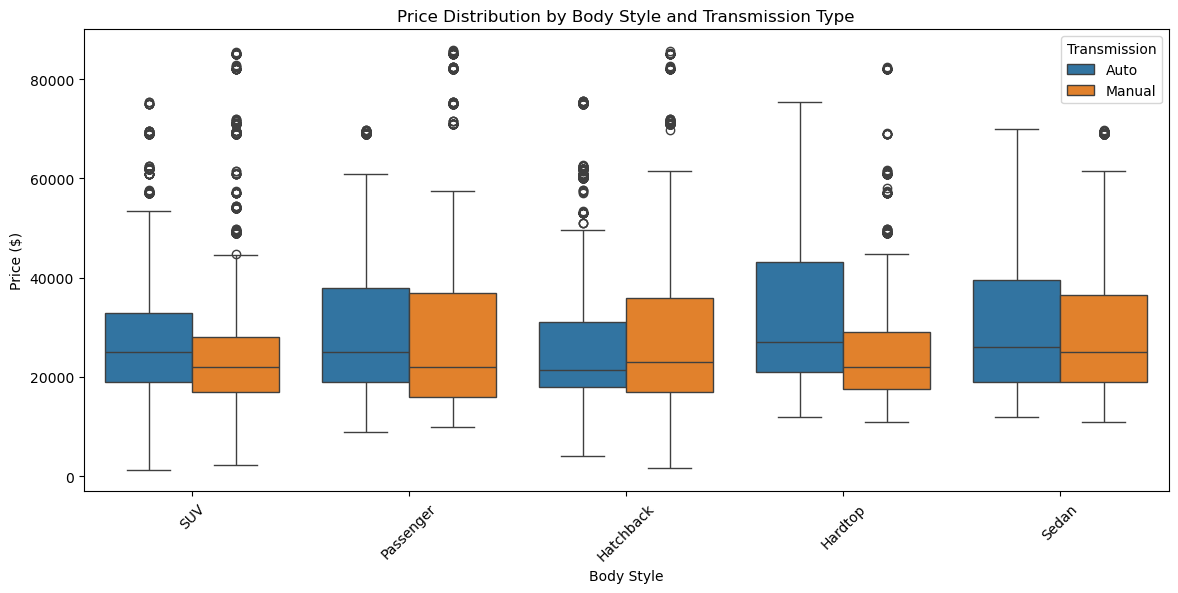

Index(['Car_id', 'Date', 'Customer Name', 'Gender', 'Annual Income',
       'Dealer_Name', 'Company', 'Model', 'Engine', 'Transmission', 'Color',
       'Price ($)', 'Dealer_No ', 'Body Style', 'Phone', 'Dealer_Region',
       'Income_Group', 'Date of Sale'],
      dtype='object')

In [36]:
#13 How does the car price distribution change when considering different combinations of body style and transmission type
distribution=df.groupby(["Body Style","Transmission"])["Price ($)"].describe()
print(distribution)

plt.figure(figsize=(14, 6))
sns.boxplot(x="Body Style", y="Price ($)", hue="Transmission", data=df)
plt.title("Price Distribution by Body Style and Transmission Type")
plt.xlabel("Body Style")
plt.ylabel("Price ($)")
plt.legend(title="Transmission")
plt.xticks(rotation=45)
plt.show()
df.columns

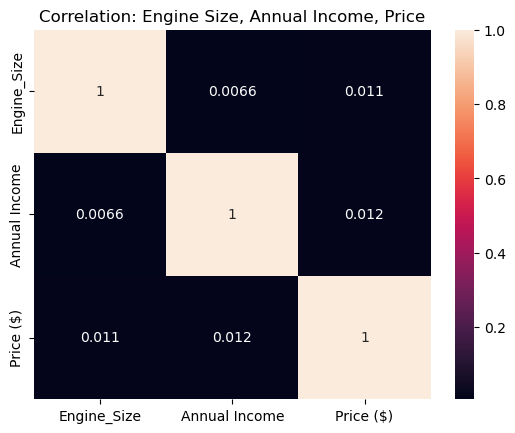

In [37]:
#14 What is the correlation between car price, engine size, and annual income of customers, and how do these features interact
def intoNum(x):    
    if x=="Overhead Camshaft" :
        return 0
    else:
        return 1
df["Engine_Size"]=df["Engine"].apply(intoNum)
rel=df[["Engine_Size","Annual Income","Price ($)"]].corr()
sns.heatmap(rel,annot=True)
plt.title("Correlation: Engine Size, Annual Income, Price")
plt.show()

In [38]:
#15 How does the average car price vary across different car models and engine types?
df.groupby(["Model","Engine"])["Price ($)"].mean().reset_index()

,Model,Engine,Price ($)
0,3-Sep,DoubleÂ Overhead Camshaft,37986.380117
1,3000GT,DoubleÂ Overhead Camshaft,22764.326923
2,3000GT,Overhead Camshaft,21770.659864
3,300M,DoubleÂ Overhead Camshaft,21394.888889
4,323i,DoubleÂ Overhead Camshaft,16744.632287
...,...,...,...
256,Windstar,Overhead Camshaft,17100.272727
257,Wrangler,DoubleÂ Overhead Camshaft,21145.294737
258,Wrangler,Overhead Camshaft,18742.942029
259,Xterra,DoubleÂ Overhead Camshaft,15940.459459


---------------------------------

****EDA_3*****

----------------------------------------

In [39]:
df3=pd.read_csv("Amazon.csv")
df3

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1460,B08L7J3T31,Noir Aqua - 5pcs PP Spun Filter + 1 Spanner | ...,Home&Kitchen|Kitchen&HomeAppliances|WaterPurif...,₹379,₹919,59%,4,"1,090",SUPREME QUALITY 90 GRAM 3 LAYER THIK PP SPUN F...,"AHITFY6AHALOFOHOZEOC6XBP4FEA,AFRABBODZJZQB6Z4U...","Prabha ds,Raghuram bk,Real Deal,Amazon Custome...","R3G3XFHPBFF0E8,R3C0BZCD32EIGW,R2EBVBCN9QPD9R,R...","Received the product without spanner,Excellent...","I received product without spanner,Excellent p...",https://m.media-amazon.com/images/I/41fDdRtjfx...,https://www.amazon.in/Noir-Aqua-Spanner-Purifi...
1461,B01M6453MB,Prestige Delight PRWO Electric Rice Cooker (1 ...,Home&Kitchen|Kitchen&HomeAppliances|SmallKitch...,"₹2,280","₹3,045",25%,4.1,"4,118","230 Volts, 400 watts, 1 Year","AFG5FM3NEMOL6BNFRV2NK5FNJCHQ,AGEINTRN6Z563RMLH...","Manu Bhai,Naveenpittu,Evatira Sangma,JAGANNADH...","R3DDL2UPKQ2CK9,R2SYYU1OATVIU5,R1VM993161IYRW,R...","ok,everything was good couldn't return bcoz I ...","ok,got everything as mentioned but the me

In [40]:
df3.isnull().sum()

product_id             0
product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
rating_count           2
about_product          0
user_id                0
user_name              0
review_id              0
review_title           0
review_content         0
img_link               0
product_link           0
dtype: int64

In [41]:
#1 What is the average rating for each product category
df3["rating"]=df3["rating"].astype(str).apply(lambda x: np.nan if x=="|" else x.strip())
df3.rating= df3["rating"].astype(float)
avg_val=df3.groupby("category")["rating"].mean().reset_index()
print(avg_val)

                                              category    rating
0    Car&Motorbike|CarAccessories|InteriorAccessori...  3.800000
1    Computers&Accessories|Accessories&Peripherals|...  4.150000
2    Computers&Accessories|Accessories&Peripherals|...  3.500000
3    Computers&Accessories|Accessories&Peripherals|...  3.600000
4    Computers&Accessories|Accessories&Peripherals|...  4.050000
..                                                 ...       ...
206  OfficeProducts|OfficePaperProducts|Paper|Stati...  4.250000
207  OfficeProducts|OfficePaperProducts|Paper|Stati...  4.150000
208  OfficeProducts|OfficePaperProducts|Paper|Stati...  4.300000
209  OfficeProducts|OfficePaperProducts|Paper|Stati...  4.133333
210  Toys&Games|Arts&Crafts|Drawing&PaintingSupplie...  4.300000

[211 rows x 2 columns]


In [42]:
#2 What are the top rating_count products by category
df_top=df3.groupby("category")["rating_count"].sum().sort_values(ascending=False).reset_index()
df_top.columns = ["Category", "Total Ratings"]
df_top

,Category,Total Ratings
0,"Electronics|Headphones,Earbuds&Accessories|Hea...","97,1751,07,15133,58460,02613,79742,77597,17491..."
1,Computers&Accessories|NetworkingDevices|Networ...,"95,116"
2,Electronics|Cameras&Photography|SecurityCamera...,"93,1121,8803,60644,6965,554"
3,Computers&Accessories|Components|InternalSolid...,"92,9253,0292,515"
4,Computers&Accessories|Accessories&Peripherals|...,"9,94011,3309,7012,8681,09222,860"
...,...,...
206,Electronics|Mobiles&Accessories|MobileAccessor...,"1,193"
207,Car&Motorbike|CarAccessories|InteriorAccessori...,"1,118"
208,Home&Kitchen|Kitchen&HomeAppliances|SewingMach...,"1,06713,2512,4492,283"
209,"Home&Kitchen|Kitchen&HomeAppliances|Coffee,Tea...","1,065"


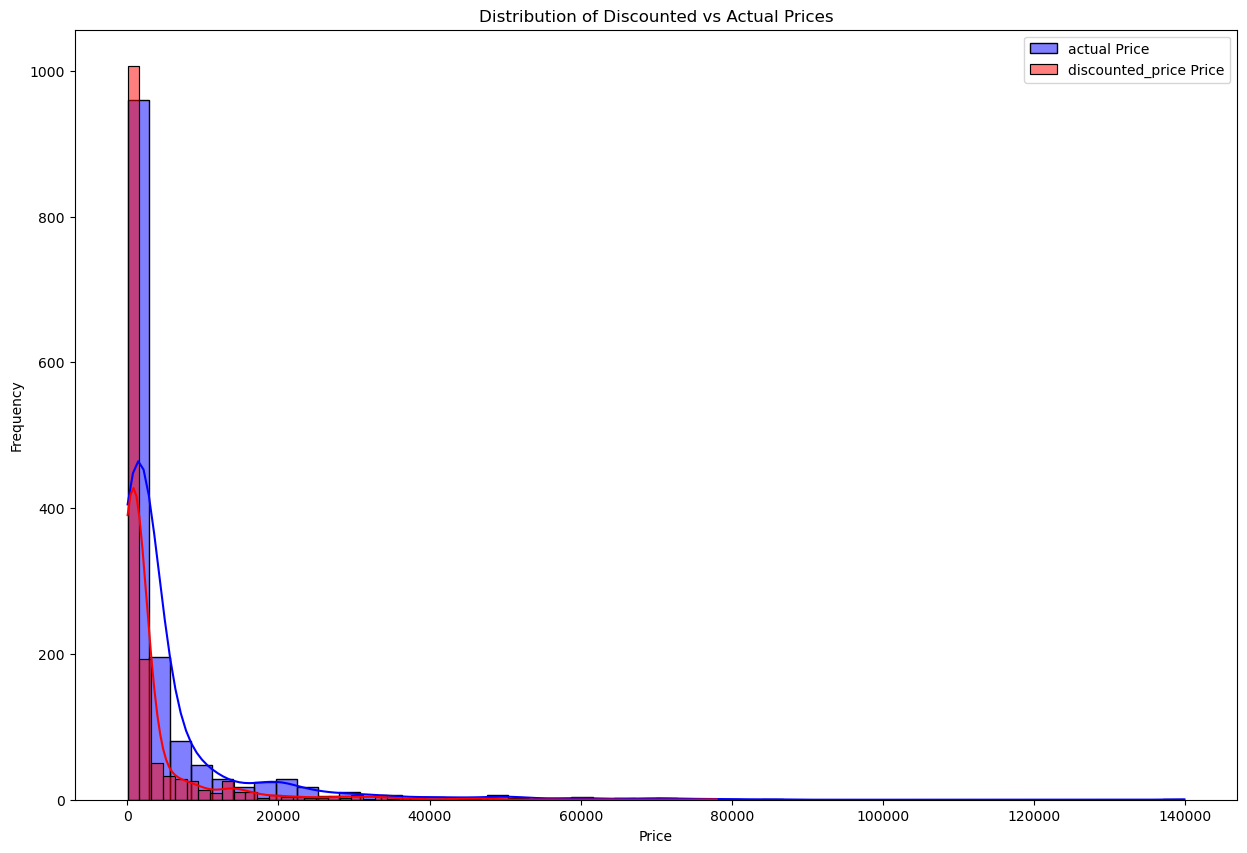

In [43]:
#3 What is the distribution of discounted prices vs. actual prices
df3.dtypes

df3["actual_price"] = pd.to_numeric(
    df3["actual_price"]
    .astype(str)                         # Convert to string
    .str.replace("₹", "", regex=False)   # Remove currency symbol
    .str.replace(",", "", regex=False),  # Remove commas
    errors='coerce'                      # Invalid entries become NaN
)

df3["discounted_price"]=pd.to_numeric(df3["discounted_price"].astype(str).str.replace("₹","").str.replace(",",""))
plt.figure(figsize=(15,10))
sns.histplot(df3["actual_price"],kde=True,color="blue",label="actual Price",bins=50)
sns.histplot(df3["discounted_price"],kde=True,color="red",label="discounted_price Price",bins=50)

plt.title("Distribution of Discounted vs Actual Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [44]:
df3["actual_price"]

0       1099.0
1        349.0
2       1899.0
3        699.0
4        399.0
         ...  
1460     919.0
1461    3045.0
1462    3080.0
1463    1890.0
1464    3690.0
Name: actual_price, Length: 1465, dtype: float64

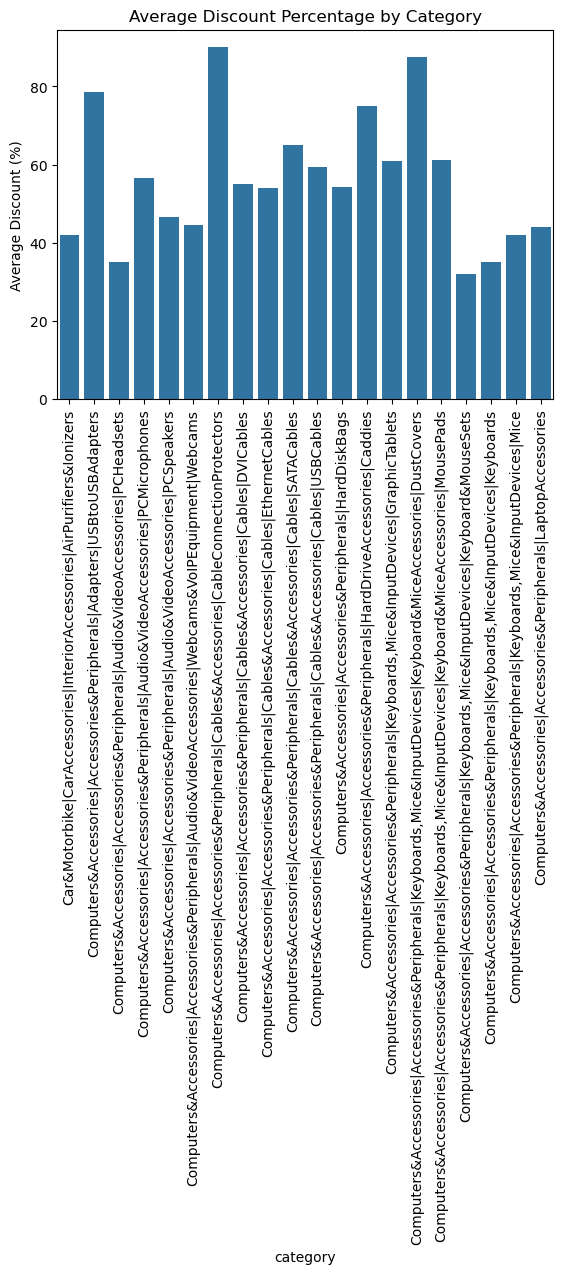

In [45]:
#4 How does the average discount percentage vary across categories
df3["discount_percentage"]=pd.to_numeric(df3["discount_percentage"].astype(str).str.replace("%",""))
data_discount_mean =df3.groupby("category")["discount_percentage"].mean().reset_index().head(20)
sns.barplot(x="category",y="discount_percentage",data=data_discount_mean)
plt.xticks(rotation=90)
plt.ylabel("Average Discount (%)")
plt.title("Average Discount Percentage by Category")
plt.show()

In [46]:
#5' What are the most popular product names
popular_products = df3["product_name"].value_counts().reset_index().head(10)
popular_products.columns = ["product_name", "count"]
print(popular_products)

                                        product_name  count
0  Fire-Boltt Ninja Call Pro Plus 1.83" Smart Wat...      5
1  Fire-Boltt Phoenix Smart Watch with Bluetooth ...      4
2  Wayona Nylon Braided USB to Lightning Fast Cha...      3
3  MI Braided USB Type-C Cable for Charging Adapt...      3
4  Amazonbasics Nylon Braided Usb-C To Lightning ...      3
5  Samsung Galaxy M13 5G (Aqua Green, 6GB, 128GB ...      3
6  Amazon Basics USB Type-C to USB-A 2.0 Male Fas...      3
7  boAt A400 USB Type-C to USB-A 2.0 Male Data Ca...      3
8  Duracell USB C To Lightning Apple Certified (M...      3
9  AmazonBasics New Release Nylon USB-A to Lightn...      3


In [47]:
#6 What are the most popular product keywords
from collections import Counter
keywords= df3["about_product"].dropna().str.lower().str.split().reset_index(drop=True)
keyword=[k for line in keywords for k in line ]

stop_words = [
    'and', 'from', 'all', 'with', 'for', 'which', 'your', 'when', 'year', 'also', 'more', 'this', 'other', 'not'
]

#filtered_keywords = [word for word in keyword if word not in stop_words and word.isalpha()]

filter_Keywords=[i  for i in keyword if i not in stop_words and len(i)>4]
# Count the keywords
keyword_counts = Counter(filter_Keywords)
keyword_counts

Counter({'cable': 706,
         'charging': 548,
         'power': 438,
         'warranty': 434,
         'compatible': 367,
         'water': 354,
         'design': 353,
         'devices': 329,
         'charge': 314,
         'product': 313,
         'comes': 276,
         'speed': 261,
         'watch': 261,
         'connect': 254,
         'quality': 249,
         'device': 231,
         'battery': 227,
         'features': 217,
         'makes': 207,
         'support': 206,
         'smart': 204,
         'laptop': 200,
         'please': 198,
         'remote': 197,
         'bluetooth': 193,
         'display': 184,
         'touch': 181,
         'wireless': 181,
         'designed': 176,
         'phone': 174,
         'durable': 172,
         'android': 171,
         'camera': 171,
         'perfect': 165,
         'supports': 163,
         'easily': 162,
         'ports': 162,
         'iphone': 160,
         'charger': 158,
         'built-in': 156,
         'type-c': 

In [48]:
#7 What are the most popular product reviews
df3["rating_count"]=pd.to_numeric(df3["rating_count"].dropna().astype(str).str.replace(",",""))
top_reviewed_products = df3.groupby("product_name")["rating_count"].sum().sort_values(ascending=False).reset_index()
print(top_reviewed_products.head(5))


                                        product_name  rating_count
0  AmazonBasics Flexible Premium HDMI Cable (Blac...      853945.0
1  Amazon Basics High-Speed HDMI Cable, 6 Feet - ...      426973.0
2  Amazon Basics High-Speed HDMI Cable, 6 Feet (2...      426973.0
3  JBL C100SI Wired In Ear Headphones with Mic, J...      385177.0
4  boAt Bassheads 100 in Ear Wired Earphones with...      363713.0


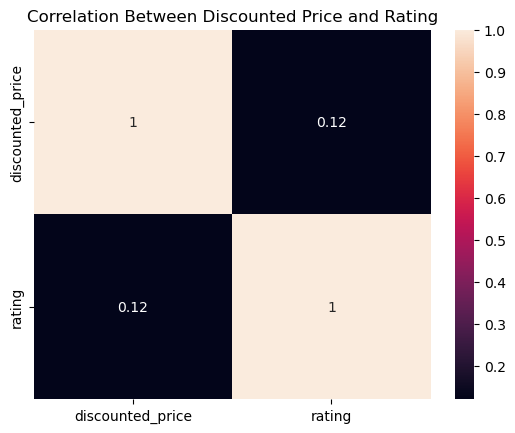

In [49]:
#8  What is the correlation between discounted_price and rating
corr= df3[["discounted_price", "rating"]].corr()
sns.heatmap(corr,annot=True)
plt.title("Correlation Between Discounted Price and Rating")
plt.show()

In [50]:
#9 What are the Top 5 categories based on the highest ratings
df3.groupby("category")["rating"].mean().sort_values(ascending=False).head(5).reset_index()

,category,rating
0,Computers&Accessories|Tablets,4.6
1,Computers&Accessories|NetworkingDevices|Networ...,4.5
2,Electronics|Cameras&Photography|Accessories|Film,4.5
3,Electronics|HomeAudio|MediaStreamingDevices|St...,4.5
4,OfficeProducts|OfficeElectronics|Calculators|B...,4.5


#10 Identify any potential areas for improvement or optimization based on the data analys
 - > . Optimize Pricing Strategies
    Observation: Some products have very high discount percentages but still receive low ratings.

    Improvement: Review pricing strategy — consider if heavy discounting is hurting brand perception or if lower-rated items are overpriced even after      discount.
 - > 


In [51]:
df3

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,399.0,1099.0,64,4.2,24269.0,High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,199.0,349.0,43,4.0,43994.0,"Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,199.0,1899.0,90,3.9,7928.0,【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,329.0,699.0,53,4.2,94363.0,The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,154.0,399.0,61,4.2,16905.0,[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1460,B08L7J3T31,Noir Aqua - 5pcs PP Spun Filter + 1 Spanner | ...,Home&Kitchen|Kitchen&HomeAppliances|WaterPurif...,379.0,919.0,59,4.0,1090.0,SUPREME QUALITY 90 GRAM 3 LAYER THIK PP SPUN F...,"AHITFY6AHALOFOHOZEOC6XBP4FEA,AFRABBODZJZQB6Z4U...","Prabha ds,Raghuram bk,Real Deal,Amazon Custome...","R3G3XFHPBFF0E8,R3C0BZCD32EIGW,R2EBVBCN9QPD9R,R...","Received the product without spanner,Excellent...","I received product without spanner,Excellent p...",https://m.media-amazon.com/images/I/41fDdRtjfx...,https://www.amazon.in/Noir-Aqua-Spanner-Purifi...
1461,B01M6453MB,Prestige Delight PRWO Electric Rice Cooker (1 ...,Home&Kitchen|Kitchen&HomeAppliances|SmallKitch...,2280.0,3045.0,25,4.1,4118.0,"230 Volts, 400 watts, 1 Year","AFG5FM3NEMOL6BNFRV2NK5FNJCHQ,AGEINTRN6Z563RMLH...","Manu Bhai,Naveenpittu,Evatira Sangma,JAGANNADH...","R3DDL2UPKQ2CK9,R2SYYU1OATVIU5,R1VM993161IYRW,R...","ok,everything was good couldn't return bcoz I ...","ok,got everything as mentioned but the measuri...",

****EDA-4***

In [52]:
df4= pd.read_csv("spotify.csv")

In [53]:
df4

,Artist,Track Name,Popularity,Duration (ms),Track ID
0,Drake,Rich Baby Daddy (feat. Sexyy Red & SZA),92,319191,1yeB8MUNeLo9Ek1UEpsyz6
1,Drake,One Dance,91,173986,1zi7xx7UVEFkmKfv06H8x0
2,Drake,IDGAF (feat. Yeat),90,260111,2YSzYUF3jWqb9YP9VXmpjE
3,Drake,First Person Shooter (feat. J. Cole),88,247444,7aqfrAY2p9BUSiupwk3svU
4,Drake,Jimmy Cooks (feat. 21 Savage),88,218364,3F5CgOj3wFlRv51JsHbxhe
...,...,...,...,...,...
435,French Montana,Splash Brothers,44,221863,3fBsEOnzwtlkpS0LxXAZhN
436,Fat Joe,All The Way Up (feat. Infared),64,191900,7Ezwtgfw7khBrpvaNPtMoT
437,A$AP Ferg,"Work REMIX (feat. A$AP Rocky, French Montana, ...",69,283693,7xVLFuuYdAvcTfcP3IG3dS
438,Diddy,Another One Of Me (feat. 21 Savage),65,220408,4hGmQboiou09EwhcTWa0H6


In [54]:
#1 Read the dataframe, check null value if present then do the needful, check duplicate row , if present then do the needful
null_value=df4.isnull().sum()
print(null_value)
duplicat= df4.duplicated().sum()
print("Before duplicate ",df4.shape)
print("dulicate ",duplicat)
df4.drop_duplicates(inplace=True)
print("After duplicate ",df4.shape)

Artist           0
Track Name       0
Popularity       0
Duration (ms)    0
Track ID         0
dtype: int64
Before duplicate  (440, 5)
dulicate  27
After duplicate  (413, 5)


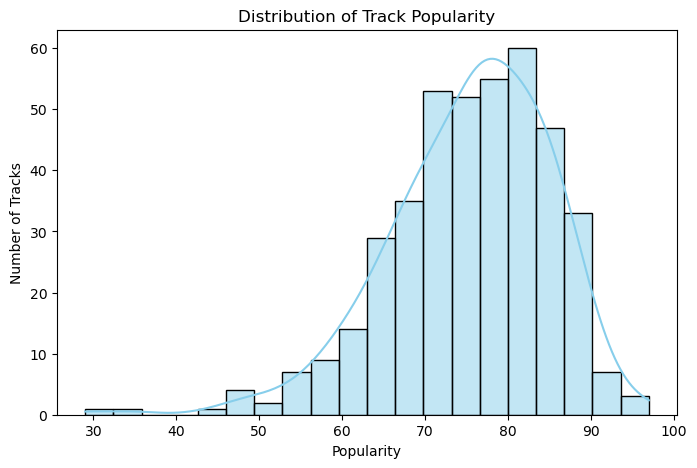

In [55]:
#2 What is the distribution of popularity among the tracks in the dataset? Visualize it using a histogram
plt.figure(figsize=(8, 5))
sns.histplot(data=df4, x="Popularity", bins=20, kde=True, color="skyblue")
plt.title("Distribution of Track Popularity")
plt.xlabel("Popularity")
plt.ylabel("Number of Tracks")
plt.show()


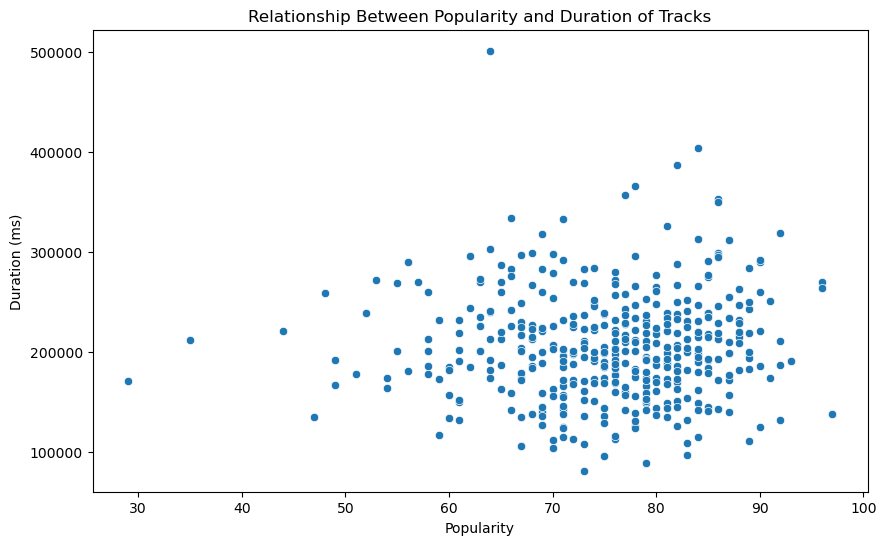

Correlation coefficient: 0.03899200928439096
NO, there is no relationship between popularity and duration


In [56]:
#3 Is there any relationship between the popularity and the duration of tracks? Explore this using a scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x="Popularity", y="Duration (ms)", data=df4)
#sns.lmplot(x="Popularity", y="Duration (ms)", data=df4)
plt.xlabel("Popularity")
plt.ylabel("Duration (ms)")
plt.title("Relationship Between Popularity and Duration of Tracks")
plt.show()

correlation = df4["Popularity"].corr(df4["Duration (ms)"])
print("Correlation coefficient:", correlation)
print("NO, there is no relationship between popularity and duration")

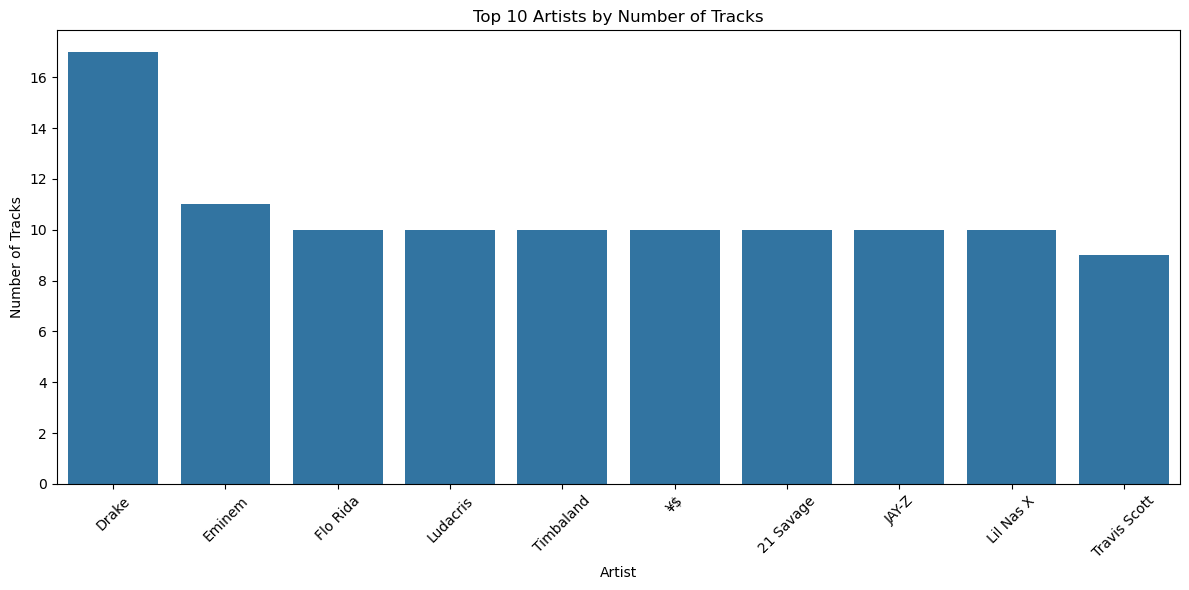

In [57]:
#4 Which artist has the highest number of tracks in the dataset? Display the count of tracks for each artist using a countplot
top_artists = df4["Artist"].value_counts().head(10).index
filtered_df = df4[df4["Artist"].isin(top_artists)]

plt.figure(figsize=(12, 6))
sns.countplot(x="Artist", data=filtered_df, order=top_artists)
plt.title("Top 10 Artists by Number of Tracks")
plt.xticks(rotation=45)
plt.ylabel("Number of Tracks")
plt.xlabel("Artist")
plt.tight_layout()
plt.show()


In [58]:
#5 What are the top 5 least popular tracks in the dataset? Provide the artist name and track name for each
df4[["Artist","Track Name","Popularity"]].sort_values(by="Popularity",ascending=True).head(5).reset_index(drop=True)

,Artist,Track Name,Popularity
0,Pressa,Attachments (feat. Coi Leray),29
1,Justin Bieber,Intentions,35
2,French Montana,Splash Brothers,44
3,Lil Baby,On Me - Remix,47
4,Wyclef Jean,911 (feat. Mary J. Blige),48


In [59]:
#6 Among the top 5 most popular artists, which artist has the highest popularity on average? Calculate and display the average popularity for each artist

popular_artist5= df4.groupby("Artist")["Popularity"].mean().sort_values(ascending=False).head(5).reset_index()
print(popular_artist5)

         Artist  Popularity
0         cassö   92.000000
1        Trueno   89.000000
2  David Guetta   87.000000
3  Travis Scott   86.555556
4            ¥$   85.100000


In [60]:
#7 For the top 5 most popular artists, what are their most popular tracks? List the track name for each artist
top_5_artist= df4.groupby("Artist")["Popularity"].mean().sort_values(ascending=False).head(5).index
top_5_artist
Most_popular_track= df4[df4["Artist"].isin(top_5_artist)].groupby("Artist")["Popularity"].max().reset_index()

data= pd.merge(Most_popular_track,df4, on=["Artist","Popularity"],how="inner")
print("their most popular tracks ",data)
print("List the track name for each artist ",df4[df4["Artist"].isin(top_5_artist)])


their most popular tracks           Artist  Popularity                    Track Name  Duration (ms)  \
0  David Guetta          87            Baby Don't Hurt Me         140017   
1  Travis Scott          93    FE!N (feat. Playboi Carti)         191700   
2        Trueno          89  Mamichula - con Nicki Nicole         219201   
3         cassö          92                         Prada         132359   
4            ¥$          96                      CARNIVAL         264324   

                 Track ID  
0  3BKD1PwArikchz2Zrlp1qi  
1  42VsgItocQwOQC3XWZ8JNA  
2  0TUW9faHNaBmi89wsYGp9y  
3  59NraMJsLaMCVtwXTSia8i  
4  3w0w2T288dec0mgeZZqoNN  
List the track name for each artist             Artist                                    Track Name  Popularity  \
7    Travis Scott                        MELTDOWN (feat. Drake)          86   
30   Travis Scott                    FE!N (feat. Playboi Carti)          93   
31   Travis Scott                                      I KNOW ?          9

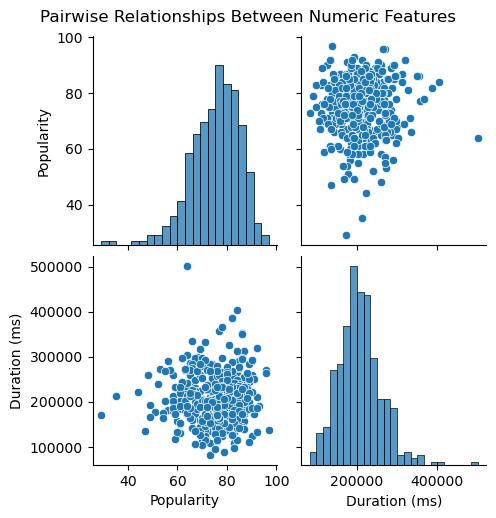

In [61]:
#8 Visualize relationships between multiple numerical variables simultaneously using a pair plot
numeric_cols = df4[["Popularity", "Duration (ms)"]]

sns.pairplot(numeric_cols)
plt.suptitle("Pairwise Relationships Between Numeric Features", y=1.02)
plt.show()

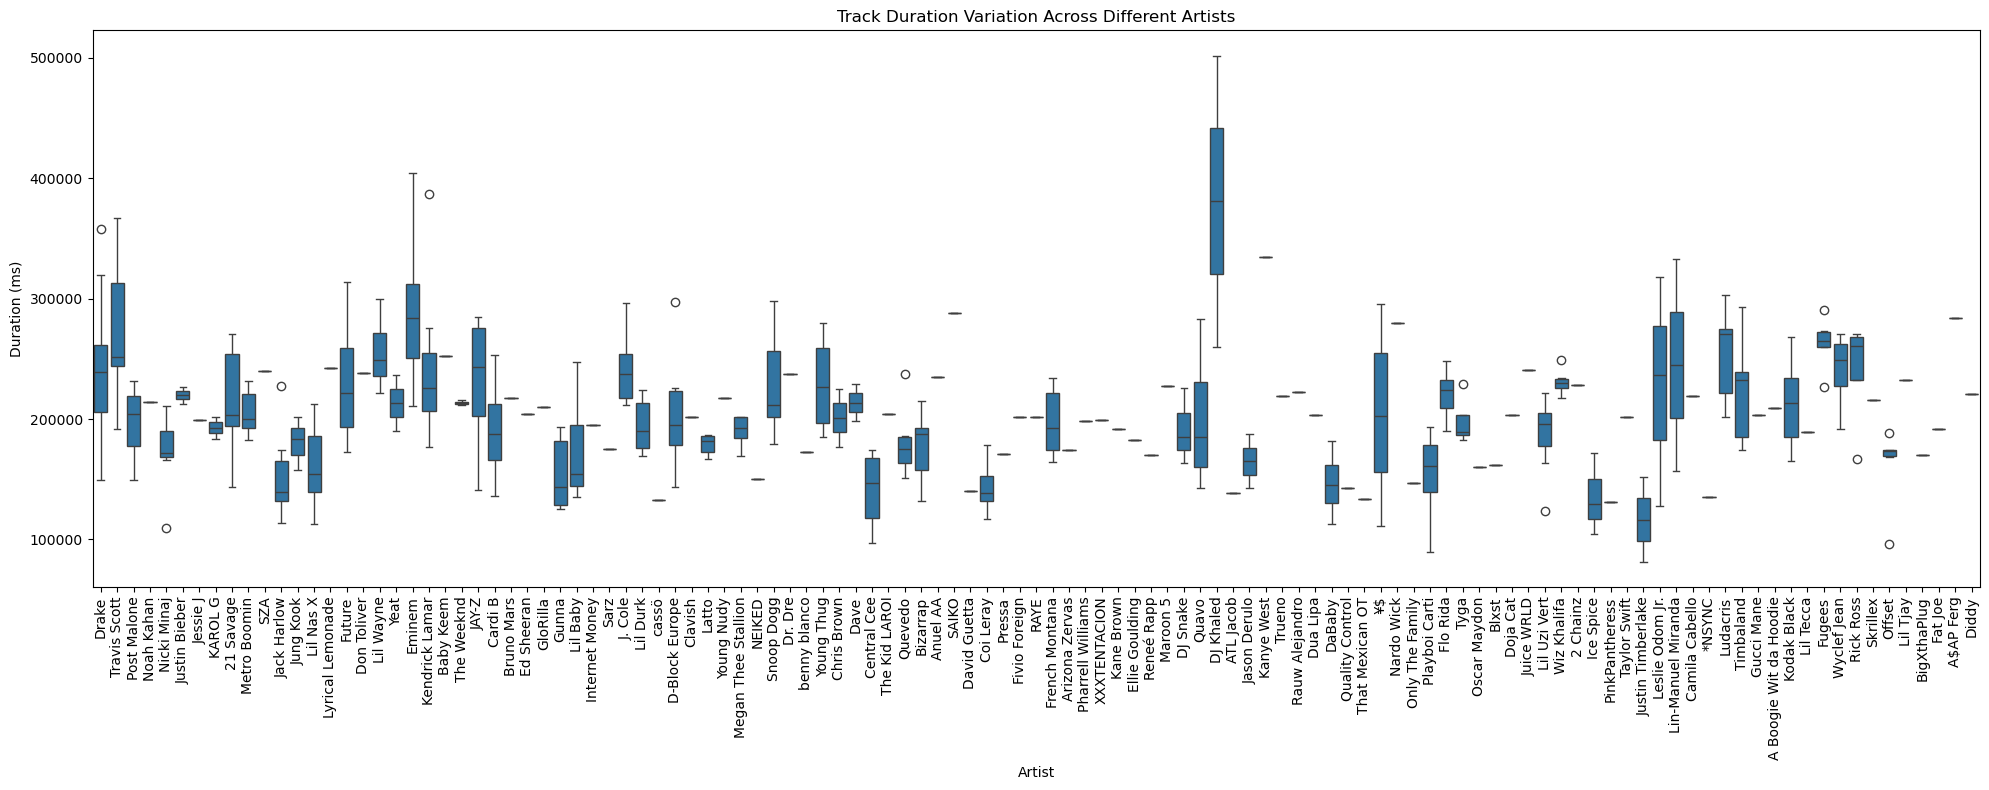

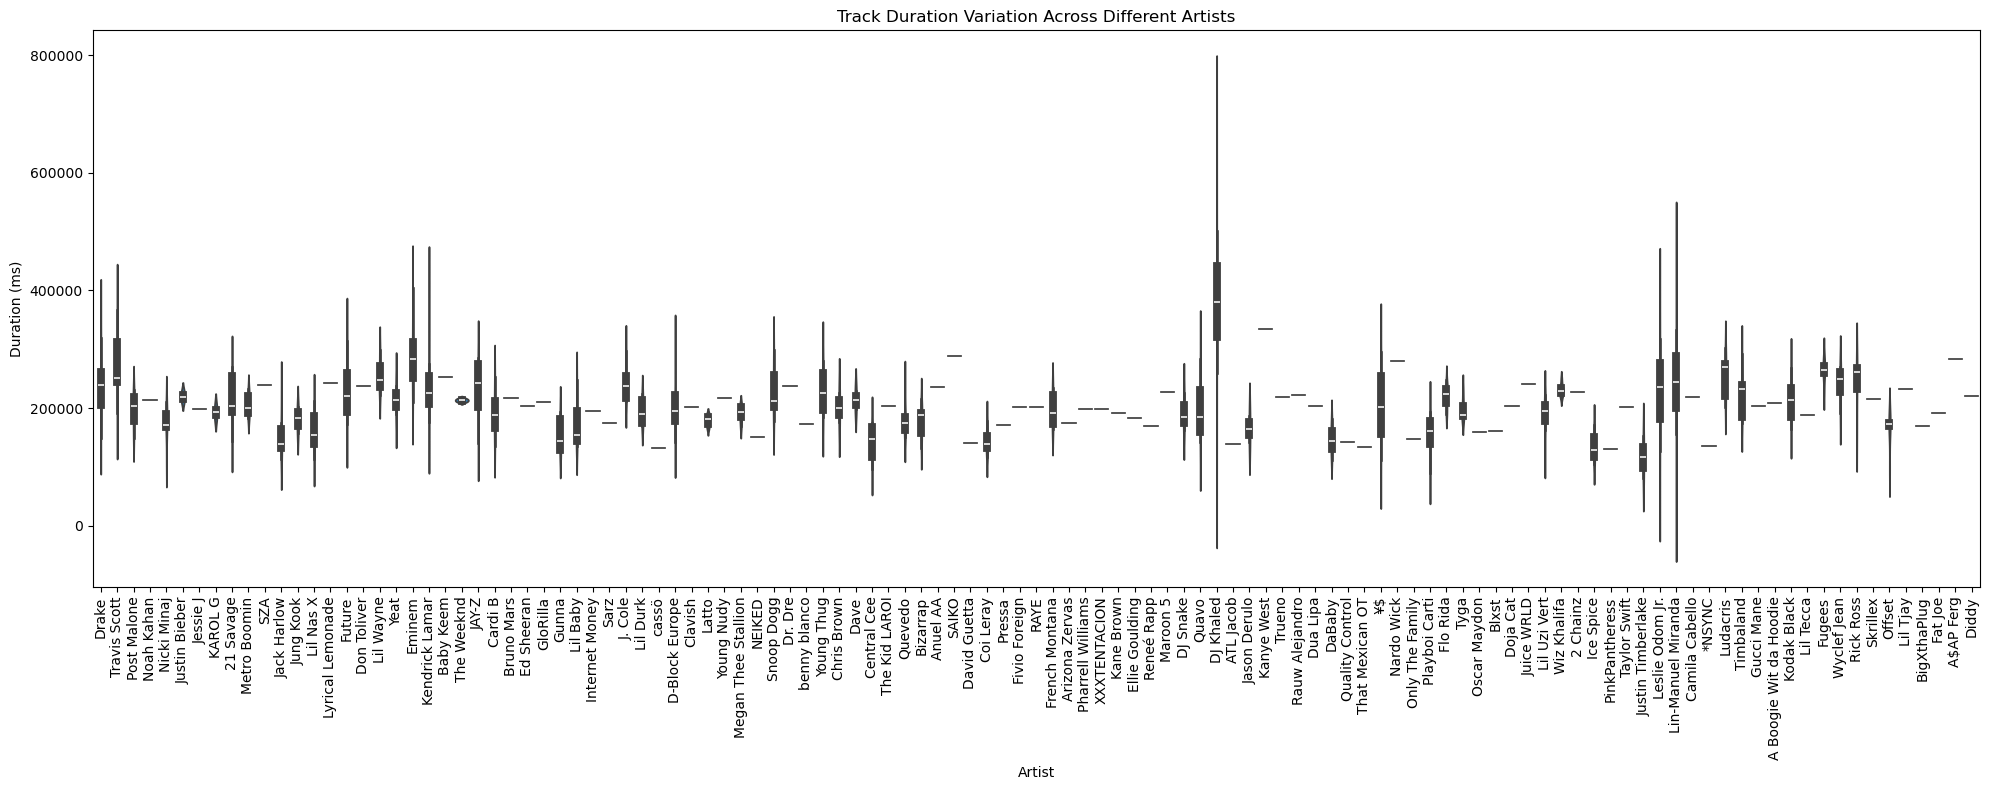

In [62]:
#9 Does the duration of tracks vary significantly across different artists? Explore this visually using a box plot or violin plot
plt.figure(figsize=(20, 8))
sns.boxplot(data=df4,y="Duration (ms)",x="Artist")
plt.xticks(rotation=90)
plt.title("Track Duration Variation Across Different Artists")
plt.ylabel("Duration (ms)")
plt.xlabel("Artist")
plt.tight_layout()
plt.show()

plt.figure(figsize=(20, 8))
sns.violinplot(data=df4,y="Duration (ms)",x="Artist")
plt.xticks(rotation=90)
plt.title("Track Duration Variation Across Different Artists")
plt.ylabel("Duration (ms)")
plt.xlabel("Artist")
plt.tight_layout()
plt.show()


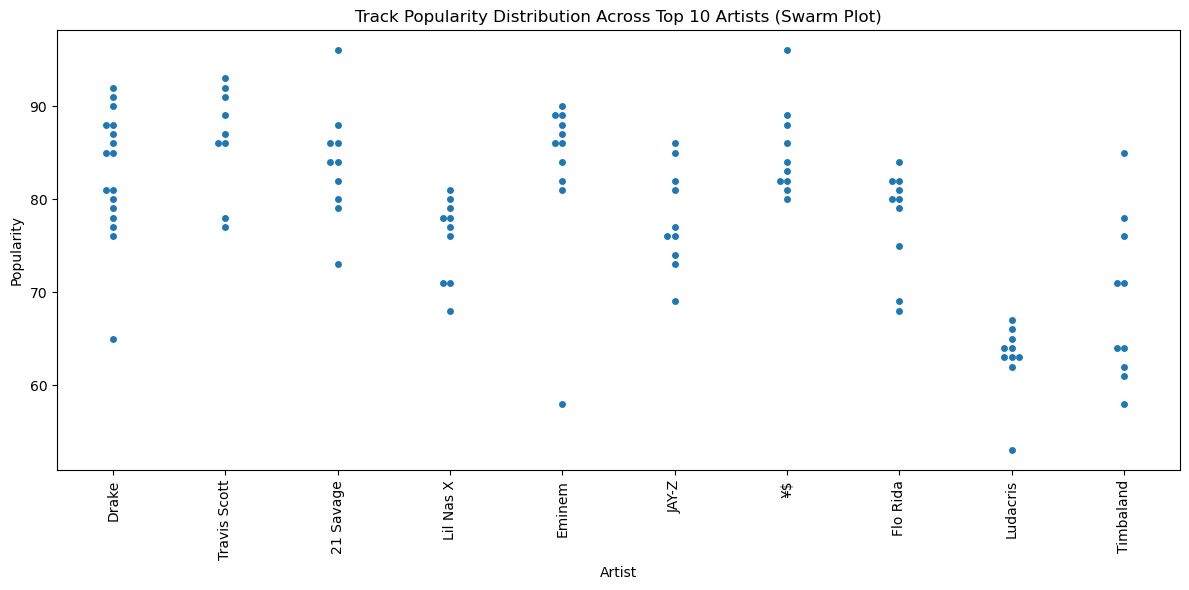

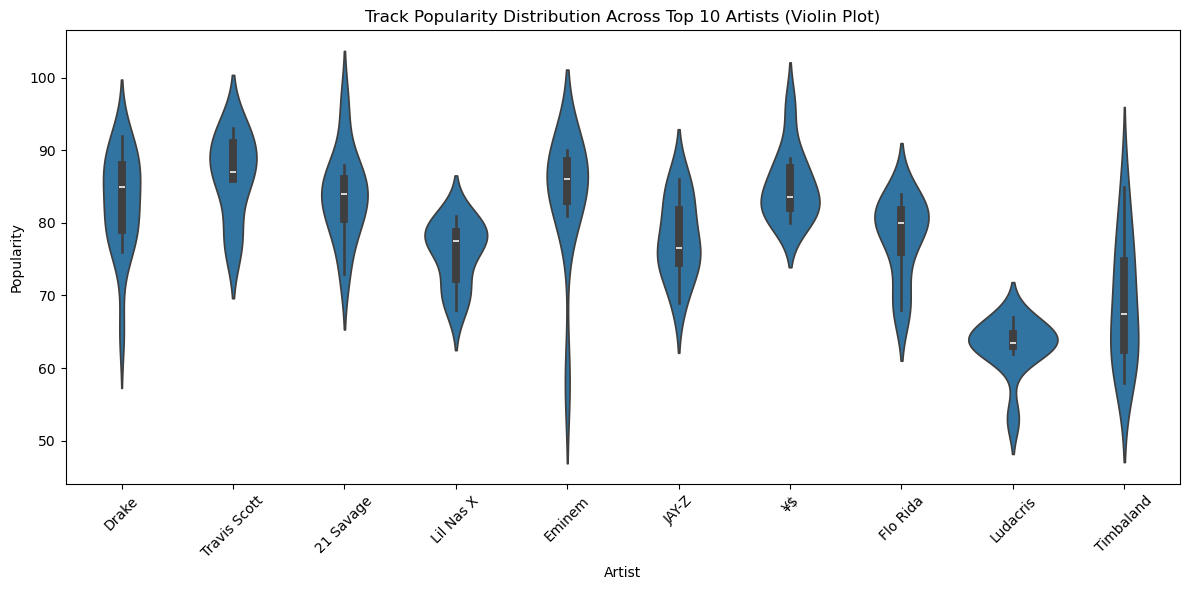

In [63]:
#10 How does the distribution of track popularity vary for different artists? Visualize this using a swarm plot or a violin plot
# Optional: Focus on top 10 most frequent artists for better visuals
top_artists = df4["Artist"].value_counts().head(10).index
filtered_df = df4[df4["Artist"].isin(top_artists)]

plt.figure(figsize=(12, 6))
sns.swarmplot(data=filtered_df, x="Artist", y="Popularity")
plt.xticks(rotation=90)
plt.title("Track Popularity Distribution Across Top 10 Artists (Swarm Plot)")
plt.ylabel("Popularity")
plt.xlabel("Artist")
plt.tight_layout()
plt.show()
plt.figure(figsize=(12, 6))
sns.violinplot(data=filtered_df, x="Artist", y="Popularity", inner="box")
plt.xticks(rotation=45)
plt.title("Track Popularity Distribution Across Top 10 Artists (Violin Plot)")
plt.tight_layout()
plt.show()



